# Pipeline Output Validation

This notebook validates the outputs of pipeline `01_extract_dataset.py` and `02_build_graph_db.py` for the new full BigCloneBench Type-4 benchmark.

Goals:

- Confirm that the benchmark files, raw graph JSON files, and cleaned graph shards refer to the same method IDs.
- Check graph availability and basic graph statistics for AST, CFG, DDG, PDG, and composed CPG.
- Verify that train pairs are covered by the extracted graph database.
- Show source code next to its graph visualization for manual sanity checking.
- Highlight suspicious cases such as missing layers, empty graphs, or train pairs with missing graph data.

In [1]:
from pathlib import Path
import json
import os
import pickle
import random
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import display, Markdown, HTML
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name and not (PROJECT_ROOT / "pipelines").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

BCB_CLONE_TYPE = "4"
BENCH_DIR = PROJECT_ROOT / "bench_data" / "bcb_full_type4"
OUTPUT_ROOT = PROJECT_ROOT.parent / "outputs" / "type4"
RAW_FEATURES_DIR = OUTPUT_ROOT / "dataset_features"
CLEAN_GRAPHS_DIR = OUTPUT_ROOT / "clean_graphs"
GRAPH_MANIFEST_PATH = CLEAN_GRAPHS_DIR / "graph_shards_manifest.json"

DATA_PATH = BENCH_DIR / "data.jsonl"
TRAIN_PATH = BENCH_DIR / "train.txt"
METADATA_PATH = BENCH_DIR / "metadata.json"
TYPE_LABELS_PATH = BENCH_DIR / "type_labels.tsv"

GRAPH_TYPES = ["ast", "cfg", "ddg", "pdg", "cpg"]
BASE_GRAPH_TYPES = ["ast", "cfg", "ddg", "pdg"]

RUN_FULL_SCAN = False  # Set to True for slower all-shard checks.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

paths = {
    "benchmark_dir": BENCH_DIR,
    "data_jsonl": DATA_PATH,
    "train_txt": TRAIN_PATH,
    "metadata_json": METADATA_PATH,
    "type_labels_tsv": TYPE_LABELS_PATH,
    "raw_features_dir": RAW_FEATURES_DIR,
    "clean_graphs_dir": CLEAN_GRAPHS_DIR,
    "graph_manifest": GRAPH_MANIFEST_PATH,
}

pd.DataFrame(
    [{"name": name, "path": str(path), "exists": path.exists()} for name, path in paths.items()]
)

,name,path,exists
0,benchmark_dir,C:\Users\koush\PyProjects\Spectral-Software\be...,True
1,data_jsonl,C:\Users\koush\PyProjects\Spectral-Software\be...,True
2,train_txt,C:\Users\koush\PyProjects\Spectral-Software\be...,True
3,metadata_json,C:\Users\koush\PyProjects\Spectral-Software\be...,True
4,type_labels_tsv,C:\Users\koush\PyProjects\Spectral-Software\be...,True
5,raw_features_dir,C:\Users\koush\PyProjects\outputs\type4\datase...,True
6,clean_graphs_dir,C:\Users\koush\PyProjects\outputs\type4\clean_...,True
7,graph_manifest,C:\Users\koush\PyProjects\outputs\type4\clean_...,True


## 1. Benchmark File Sanity Checks

This section checks the new benchmark folder only. It should not depend on the old `data/` folder.

In [2]:
def count_lines(path: Path) -> int:
    with path.open("rb") as f:
        return sum(chunk.count(b"\n") for chunk in iter(lambda: f.read(1024 * 1024), b""))

def read_metadata(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

metadata = read_metadata(METADATA_PATH)
benchmark_summary = {
    "metadata_total_pairs": metadata.get("total_pairs"),
    "metadata_type4_clones": metadata.get("type_4_clones"),
    "metadata_non_clones": metadata.get("non_clones"),
    "metadata_written_functions": metadata.get("written_functions"),
    "data_jsonl_rows": count_lines(DATA_PATH),
    "train_rows": count_lines(TRAIN_PATH),
    "type_label_rows": count_lines(TYPE_LABELS_PATH),
    "dump_source": metadata.get("dump_path"),
}
pd.DataFrame([benchmark_summary]).T.rename(columns={0: "value"})

,value
metadata_total_pairs,100000
metadata_type4_clones,30000
metadata_non_clones,70000
metadata_written_functions,151406
data_jsonl_rows,151406
train_rows,100000
type_label_rows,30000
dump_source,C:\Users\koush\PyProjects\bcb


In [3]:
def load_train_pairs(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            left, right, label = line.split("\t")[:3]
            rows.append((str(left), str(right), int(label)))
    return pd.DataFrame(rows, columns=["left_id", "right_id", "label"])

train_df = load_train_pairs(TRAIN_PATH)
display(train_df.head())
display(train_df["label"].value_counts().rename_axis("label").reset_index(name="count"))

assert len(train_df) == metadata["total_pairs"], "train.txt row count does not match metadata total_pairs."
assert int((train_df.label == 1).sum()) == metadata["type_4_clones"], "Positive count mismatch."
assert int((train_df.label == 0).sum()) == metadata["non_clones"], "Negative count mismatch."

display(Markdown("**Benchmark train file matches metadata.**"))

,left_id,right_id,label
0,11237848,15427471,0
1,3823230,12244520,0
2,15380770,21655219,0
3,6031248,21386162,1
4,19726265,20234919,0


,label,count
0,0,70000
1,1,30000


**Benchmark train file matches metadata.**

## 2. Pipeline 01 Raw Feature Output

Pipeline `01` should create one raw JSON feature file per method ID. This section checks count and a small sample of raw layer contents.

In [4]:
raw_json_files = sorted(RAW_FEATURES_DIR.glob("*.json"))
raw_ids = {path.stem for path in raw_json_files}

raw_summary = {
    "raw_json_files": len(raw_json_files),
    "metadata_written_functions": metadata["written_functions"],
    "raw_matches_metadata": len(raw_json_files) == metadata["written_functions"],
}
pd.DataFrame([raw_summary]).T.rename(columns={0: "value"})

,value
raw_json_files,151406
metadata_written_functions,151406
raw_matches_metadata,True


In [5]:
sample_raw_path = raw_json_files[0]
with sample_raw_path.open("r", encoding="utf-8") as f:
    sample_raw = json.load(f)

sample_rows = []
for gtype in BASE_GRAPH_TYPES:
    layer = sample_raw["features"].get(gtype, {})
    sample_rows.append({
        "method_id": sample_raw["idx"],
        "graph_type": gtype,
        "nodes": layer.get("nodes"),
        "edges": layer.get("edges"),
        "has_graph_data": layer.get("graph_data") is not None,
    })

pd.DataFrame(sample_rows)

,method_id,graph_type,nodes,edges,has_graph_data
0,10000057,ast,153,152,True
1,10000057,cfg,57,63,True
2,10000057,ddg,43,136,True
3,10000057,pdg,51,157,True


## 3. Pipeline 02 Cleaned Graph Shard Validation

Pipeline `02` now writes graph shards instead of one huge pickle file. This avoids the previous `MemoryError` and makes the output easier to validate.

In [6]:
with GRAPH_MANIFEST_PATH.open("r", encoding="utf-8") as f:
    graph_manifest = json.load(f)

manifest_summary = {
    "format": graph_manifest.get("format"),
    "shard_size": graph_manifest.get("shard_size"),
    "total_methods": graph_manifest.get("total_methods"),
    "total_base_layers_cleaned": graph_manifest.get("total_base_layers_cleaned"),
    "num_shards": len(graph_manifest.get("shards", [])),
    "all_shards_exist": all(Path(p).exists() for p in graph_manifest.get("shards", [])),
}
pd.DataFrame([manifest_summary]).T.rename(columns={0: "value"})

,value
format,cleaned_graph_shards_v1
shard_size,1000
total_methods,151406
total_base_layers_cleaned,585043
num_shards,152
all_shards_exist,True


In [7]:
def iter_graph_shards(limit=None):
    shard_paths = graph_manifest["shards"]
    if limit is not None:
        shard_paths = shard_paths[:limit]
    for shard_path in tqdm(shard_paths, desc="Loading graph shards", unit="shard"):
        with Path(shard_path).open("rb") as f:
            yield Path(shard_path), pickle.load(f)

scan_limit = None if RUN_FULL_SCAN else min(5, len(graph_manifest["shards"]))
layer_counts = Counter()
node_stats = defaultdict(list)
edge_stats = defaultdict(list)
empty_counts = Counter()
scanned_methods = 0

for shard_path, shard in iter_graph_shards(limit=scan_limit):
    for method_id, layers in shard.items():
        scanned_methods += 1
        for gtype in GRAPH_TYPES:
            graph = layers.get(gtype)
            if graph is not None and graph.number_of_nodes() > 0:
                layer_counts[gtype] += 1
                node_stats[gtype].append(graph.number_of_nodes())
                edge_stats[gtype].append(graph.number_of_edges())
            else:
                empty_counts[gtype] += 1

rows = []
for gtype in GRAPH_TYPES:
    nodes = pd.Series(node_stats[gtype], dtype="float64")
    edges = pd.Series(edge_stats[gtype], dtype="float64")
    rows.append({
        "graph_type": gtype,
        "scanned_methods": scanned_methods,
        "non_empty": layer_counts[gtype],
        "empty_or_missing": empty_counts[gtype],
        "coverage": layer_counts[gtype] / max(1, scanned_methods),
        "nodes_mean": nodes.mean(),
        "nodes_median": nodes.median(),
        "nodes_max": nodes.max(),
        "edges_mean": edges.mean(),
        "edges_median": edges.median(),
        "edges_max": edges.max(),
    })

stats_df = pd.DataFrame(rows)
display(stats_df)

note = "full scan" if RUN_FULL_SCAN else f"first {scan_limit} shards only"
display(Markdown(f"Graph statistics above are computed over **{note}**."))

Loading graph shards:   0%|          | 0/5 [00:00<?, ?shard/s]

,graph_type,scanned_methods,non_empty,empty_or_missing,coverage,nodes_mean,nodes_median,nodes_max,edges_mean,edges_median,edges_max
0,ast,5000,4849,151,0.9698,43.487111,17.0,1547.0,42.487111,16.0,1546.0
1,cfg,5000,4849,151,0.9698,17.124149,6.0,713.0,17.453496,6.0,737.0
2,ddg,5000,4847,153,0.9694,16.930060,8.0,552.0,40.115742,14.0,2121.0
3,pdg,5000,4847,153,0.9694,18.180318,8.0,665.0,47.066639,14.0,2519.0
4,cpg,5000,4849,151,0.9698,43.490823,17.0,1547.0,93.517426,30.0,4151.0


Graph statistics above are computed over **first 5 shards only**.

## 4. Method ID Coverage Checks

This section checks whether the code dataset, raw graph JSON files, cleaned graph shards, and train pairs agree on method IDs.

In [8]:
def iter_data_jsonl(path: Path):
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                yield json.loads(line)

data_ids = set()
for record in tqdm(iter_data_jsonl(DATA_PATH), total=metadata["written_functions"], desc="Reading data.jsonl", unit="method"):
    data_ids.add(str(record["idx"]))

cleaned_ids = set()
for _, shard in iter_graph_shards(limit=None if RUN_FULL_SCAN else min(10, len(graph_manifest["shards"]))):
    cleaned_ids.update(map(str, shard.keys()))

train_ids = set(train_df["left_id"]).union(set(train_df["right_id"]))

coverage_rows = [
    {"check": "data IDs vs raw JSON IDs", "left_count": len(data_ids), "right_count": len(raw_ids), "missing_left_in_right": len(data_ids - raw_ids), "missing_right_in_left": len(raw_ids - data_ids)},
    {"check": "train IDs vs data IDs", "left_count": len(train_ids), "right_count": len(data_ids), "missing_left_in_right": len(train_ids - data_ids), "missing_right_in_left": None},
    {"check": "sampled cleaned IDs vs data IDs", "left_count": len(cleaned_ids), "right_count": len(data_ids), "missing_left_in_right": len(cleaned_ids - data_ids), "missing_right_in_left": None},
]
pd.DataFrame(coverage_rows)

Reading data.jsonl:   0%|          | 0/151406 [00:00<?, ?method/s]

Loading graph shards:   0%|          | 0/10 [00:00<?, ?shard/s]

,check,left_count,right_count,missing_left_in_right,missing_right_in_left
0,data IDs vs raw JSON IDs,151406,151406,0,0.0
1,train IDs vs data IDs,151406,151406,0,NaN
2,sampled cleaned IDs vs data IDs,10000,151406,0,NaN


If `RUN_FULL_SCAN = False`, the cleaned-ID check only samples shards. Set it to `True` near the top of the notebook for a full all-shard coverage check.

## 5. Source Code Lookup and Graph Loading Helpers

The next cells provide helpers for inspecting individual methods. They load only the requested methods instead of loading all source code or all graph shards into memory.

In [9]:
def load_code_records(method_ids):
    wanted = {str(mid) for mid in method_ids}
    found = {}
    for record in iter_data_jsonl(DATA_PATH):
        method_id = str(record["idx"])
        if method_id in wanted:
            found[method_id] = record.get("func", "")
            if len(found) == len(wanted):
                break
    return found

def load_graph_records(method_ids):
    wanted = {str(mid) for mid in method_ids}
    found = {}
    for _, shard in iter_graph_shards(limit=None):
        for method_id in list(wanted):
            if method_id in shard:
                found[method_id] = shard[method_id]
                wanted.remove(method_id)
        if not wanted:
            break
    return found

def graph_label(graph, node):
    data = graph.nodes[node]
    ntype = str(data.get("type", ""))[:24]
    label = str(data.get("label", ""))[:24]
    return ntype if not label or label == ntype else f"{ntype}\n{label}"

def draw_graph(graph, ax, title, max_nodes=80):
    if graph is None or graph.number_of_nodes() == 0:
        ax.text(0.5, 0.5, "Empty or missing graph", ha="center", va="center")
        ax.set_title(title)
        ax.axis("off")
        return
    display_graph = graph
    if graph.number_of_nodes() > max_nodes:
        selected_nodes = list(graph.nodes())[:max_nodes]
        display_graph = graph.subgraph(selected_nodes).copy()
        title = f"{title} (first {max_nodes}/{graph.number_of_nodes()} nodes)"
    pos = nx.spring_layout(display_graph, seed=RANDOM_SEED, k=0.9)
    labels = {node: graph_label(display_graph, node) for node in display_graph.nodes()}
    nx.draw_networkx_edges(display_graph, pos, ax=ax, alpha=0.35, arrows=True, arrowsize=8, width=0.8)
    nx.draw_networkx_nodes(display_graph, pos, ax=ax, node_size=420, node_color="#9ecae1", edgecolors="#225ea8", linewidths=0.7)
    nx.draw_networkx_labels(display_graph, pos, labels=labels, ax=ax, font_size=6)
    ax.set_title(title)
    ax.axis("off")

def code_html(code):
    escaped = code.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")
    return f"<pre style='white-space: pre-wrap; font-size: 12px; line-height: 1.35; border: 1px solid #ddd; padding: 12px; max-height: 520px; overflow: auto'>{escaped}</pre>"

display(Markdown("Helpers loaded."))

Helpers loaded.

## 6. Code and Graph Side-by-Side Inspection

Use this section to manually verify that a method's source code and extracted graph are aligned. AST should usually reflect syntax structure. CFG/DDG/PDG may be smaller, empty, or less visually intuitive for simple methods.

Loading graph shards:   0%|          | 0/152 [00:00<?, ?shard/s]

### Method `11237848`

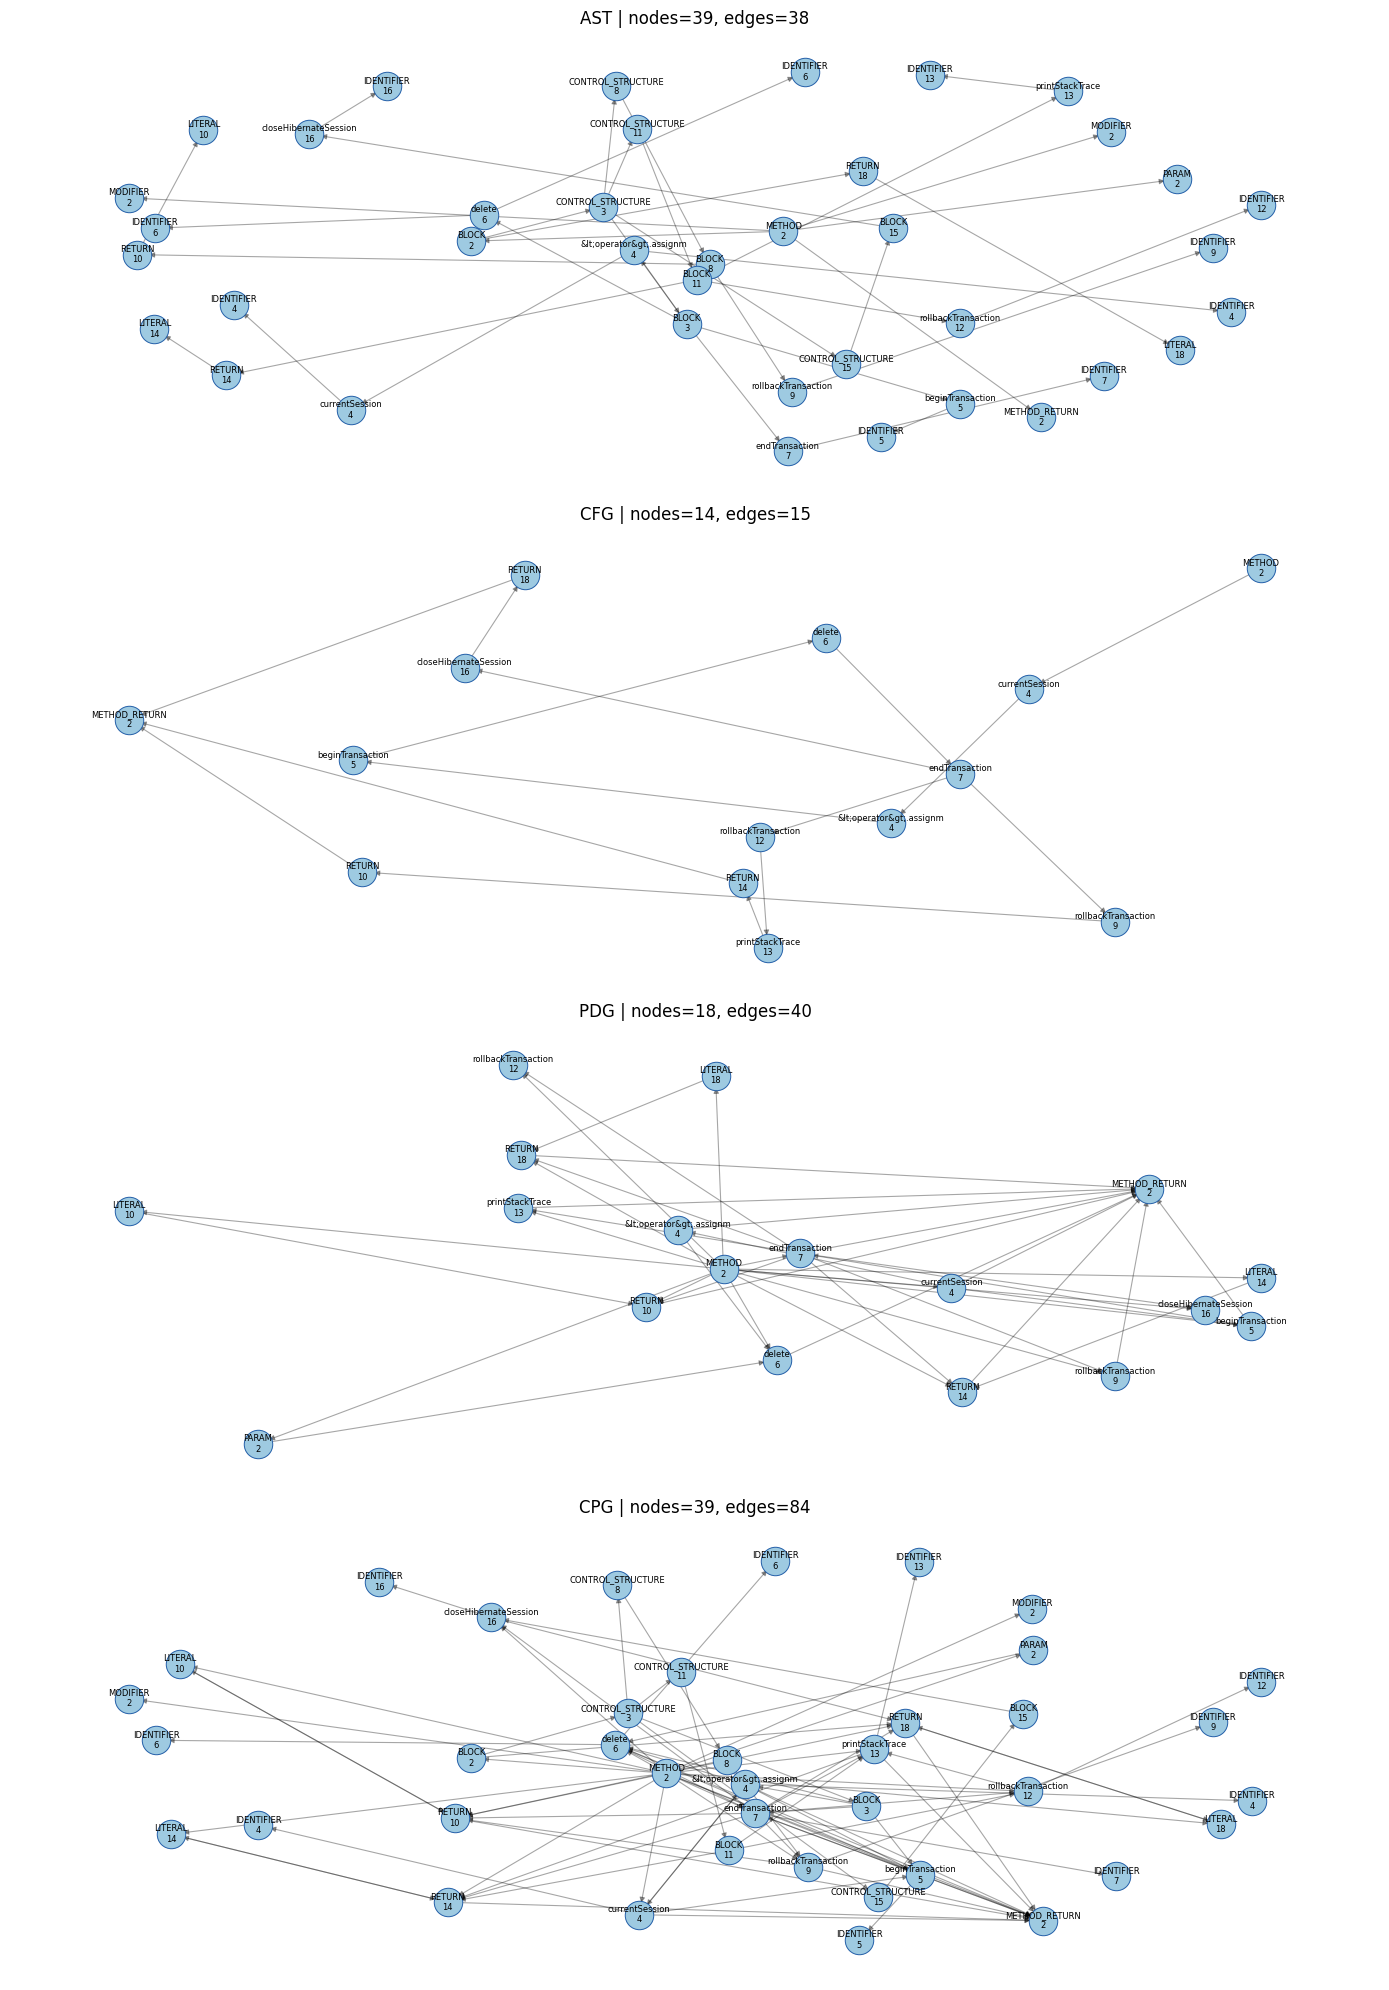

In [10]:
def show_method(method_id, layers=("ast", "cfg", "ddg", "pdg", "cpg"), max_nodes=70):
    method_id = str(method_id)
    code = load_code_records([method_id]).get(method_id, "<code not found>")
    graphs = load_graph_records([method_id]).get(method_id, {})

    display(Markdown(f"### Method `{method_id}`"))
    display(HTML(code_html(code)))

    fig, axes = plt.subplots(len(layers), 1, figsize=(14, 5 * len(layers)))
    if len(layers) == 1:
        axes = [axes]
    for ax, layer in zip(axes, layers):
        graph = graphs.get(layer)
        title = f"{layer.upper()} | nodes={graph.number_of_nodes() if graph else 0}, edges={graph.number_of_edges() if graph else 0}"
        draw_graph(graph, ax, title=title, max_nodes=max_nodes)
    plt.tight_layout()
    plt.show()

sample_method_id = train_df.iloc[0].left_id
show_method(sample_method_id, layers=("ast", "cfg", "pdg", "cpg"), max_nodes=60)

## 7. Pair-Level Inspection

This shows two methods from a train pair next to each other, then draws the selected graph layer for both. This is useful for checking Type-4 clone pairs and non-clone pairs manually.

Loading graph shards:   0%|          | 0/152 [00:00<?, ?shard/s]

### Pair `418257` vs `520600` | label=1

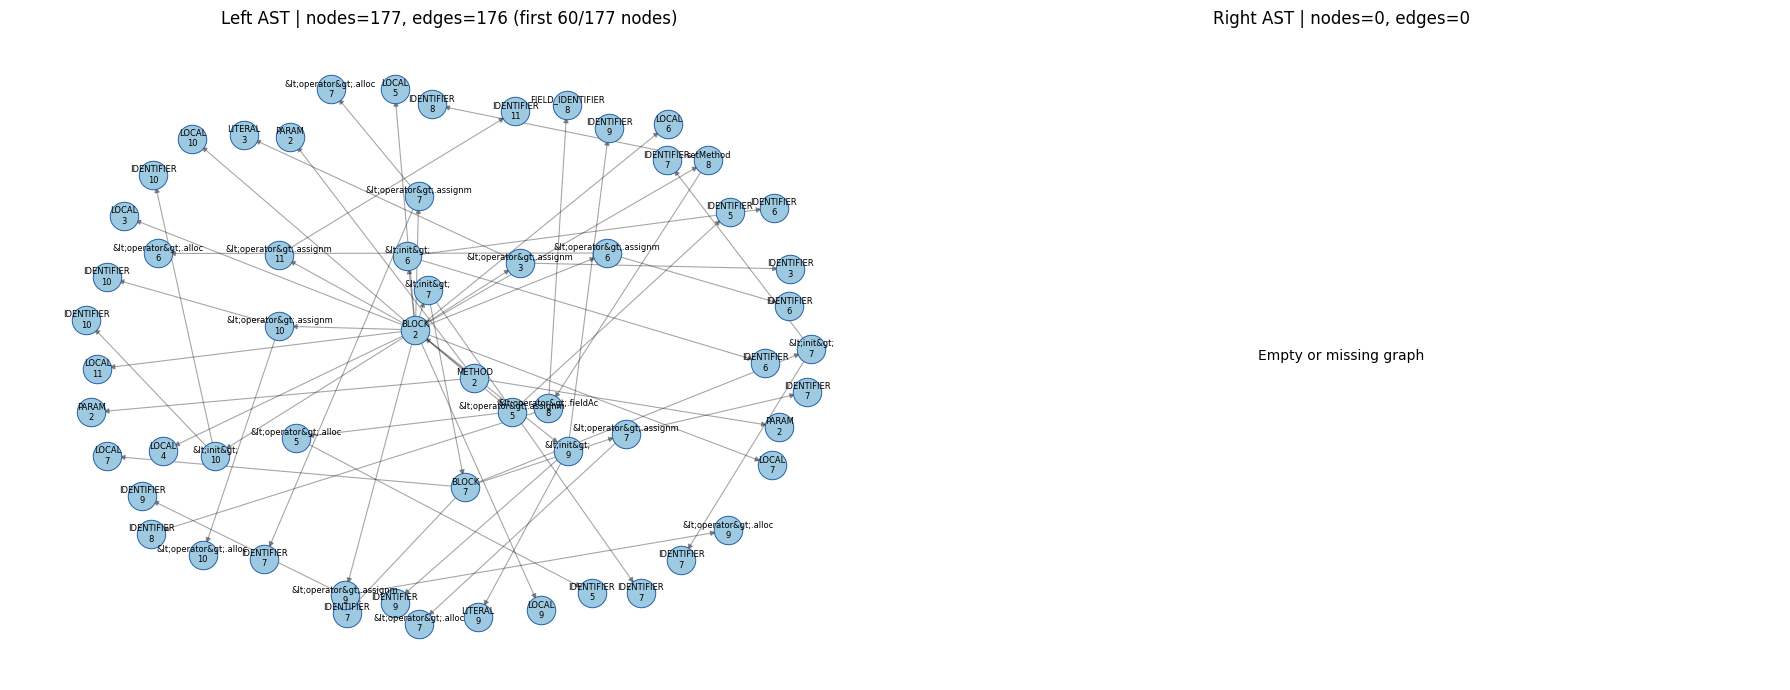

Loading graph shards:   0%|          | 0/152 [00:00<?, ?shard/s]

### Pair `3501321` vs `4757179` | label=0

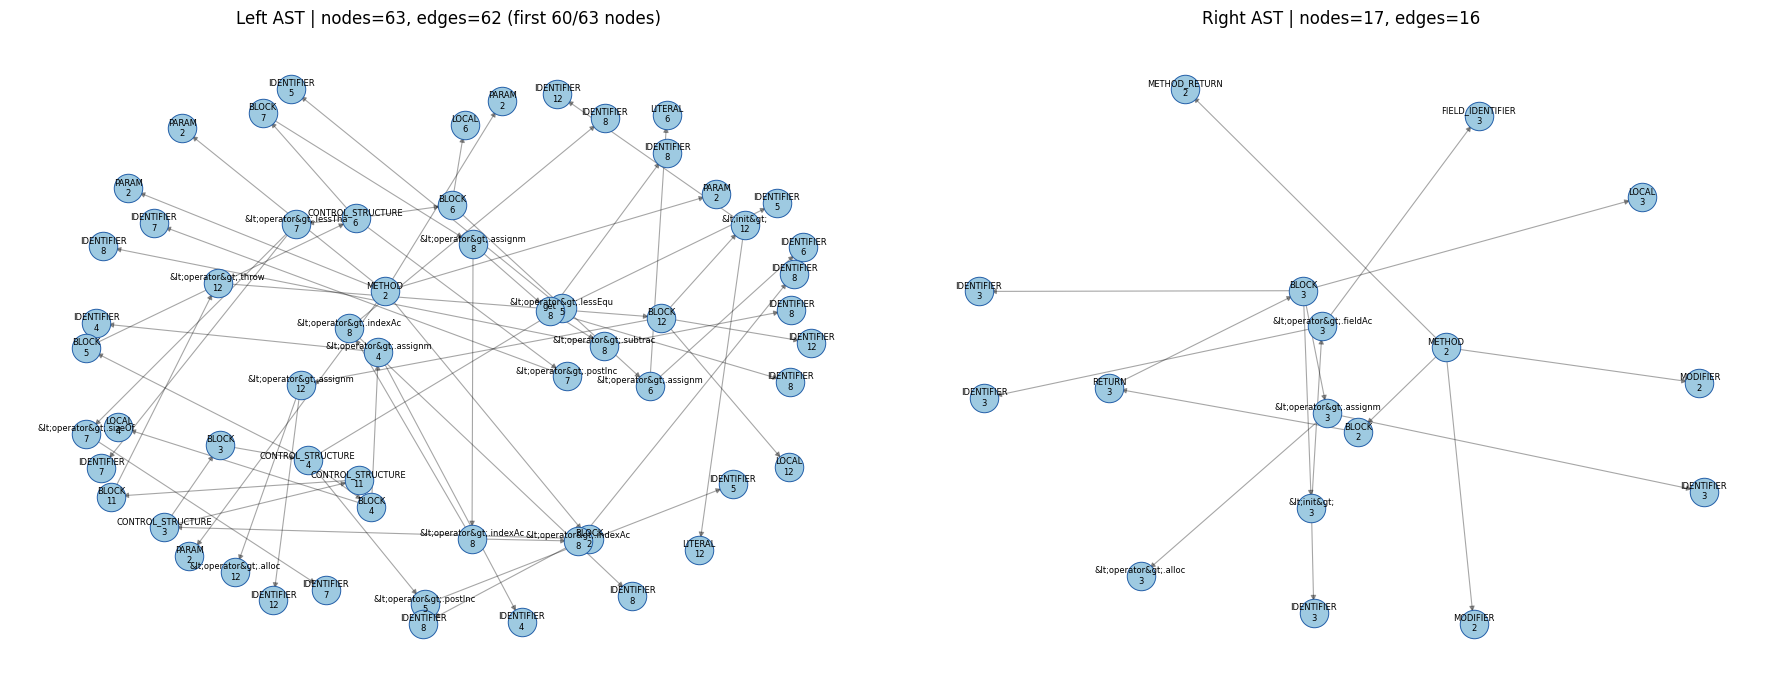

In [11]:
def show_pair(row, layer="ast", max_nodes=70):
    left_id = str(row.left_id)
    right_id = str(row.right_id)
    label = int(row.label)
    code_map = load_code_records([left_id, right_id])
    graph_map = load_graph_records([left_id, right_id])

    display(Markdown(f"### Pair `{left_id}` vs `{right_id}` | label={label}"))
    display(HTML(
        "<div style='display:grid; grid-template-columns:1fr 1fr; gap:16px'>"
        f"<div><h4>Left: {left_id}</h4>{code_html(code_map.get(left_id, '<missing>'))}</div>"
        f"<div><h4>Right: {right_id}</h4>{code_html(code_map.get(right_id, '<missing>'))}</div>"
        "</div>"
    ))

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, method_id, side in zip(axes, [left_id, right_id], ["Left", "Right"]):
        graph = graph_map.get(method_id, {}).get(layer)
        title = f"{side} {layer.upper()} | nodes={graph.number_of_nodes() if graph else 0}, edges={graph.number_of_edges() if graph else 0}"
        draw_graph(graph, ax, title=title, max_nodes=max_nodes)
    plt.tight_layout()
    plt.show()

positive_row = train_df[train_df.label == 1].sample(1, random_state=RANDOM_SEED).iloc[0]
negative_row = train_df[train_df.label == 0].sample(1, random_state=RANDOM_SEED).iloc[0]

show_pair(positive_row, layer="ast", max_nodes=60)
show_pair(negative_row, layer="ast", max_nodes=60)

## 8. Suspicious Case Finder

This cell samples graph shards and lists methods with missing or empty layers. These cases are not always bugs: DDG/PDG may be empty for very simple code, but AST should usually exist.

In [12]:
suspicious_rows = []
max_suspicious = 50
scan_limit = None if RUN_FULL_SCAN else min(10, len(graph_manifest["shards"]))

for _, shard in iter_graph_shards(limit=scan_limit):
    for method_id, layers in shard.items():
        empty_layers = []
        for gtype in GRAPH_TYPES:
            graph = layers.get(gtype)
            if graph is None or graph.number_of_nodes() == 0:
                empty_layers.append(gtype)
        if empty_layers:
            suspicious_rows.append({"method_id": method_id, "empty_or_missing_layers": ", ".join(empty_layers)})
        if len(suspicious_rows) >= max_suspicious:
            break
    if len(suspicious_rows) >= max_suspicious:
        break

suspicious_df = pd.DataFrame(suspicious_rows)
display(suspicious_df)

if not suspicious_df.empty:
    display(Markdown("Run `show_method(<method_id>)` on any suspicious method to inspect it manually."))

Loading graph shards:   0%|          | 0/10 [00:00<?, ?shard/s]

,method_id,empty_or_missing_layers
0,1000211,"ast, cfg, ddg, pdg, cpg"
1,100058,"ast, cfg, ddg, pdg, cpg"
2,10012196,"ast, cfg, ddg, pdg, cpg"
3,1001396,"ast, cfg, ddg, pdg, cpg"
4,10016360,"ast, cfg, ddg, pdg, cpg"
5,1001865,"ast, cfg, ddg, pdg, cpg"
6,10020822,"ast, cfg, ddg, pdg, cpg"
7,10025003,"ast, cfg, ddg, pdg, cpg"
8,10029533,"ast, cfg, ddg, pdg, cpg"
9,10042408,"ast, cfg, ddg, pdg, cpg"


Run `show_method(<method_id>)` on any suspicious method to inspect it manually.

## Full Empty-Graph Audit

This full scan finds methods whose graph extraction failed completely. Empty `DDG` or `PDG` can be normal for simple methods, but empty `AST` means the method cannot produce a useful spectrum and should be excluded or repaired before threshold tuning.

In [13]:
def audit_empty_graphs():
    empty_by_layer = Counter()
    first_examples = {}
    all_empty_methods = []
    ast_empty_methods = []
    total = 0

    for _, shard in iter_graph_shards(limit=None):
        for method_id, layers in shard.items():
            total += 1
            empty_layers = []
            for gtype in GRAPH_TYPES:
                graph = layers.get(gtype)
                if graph is None or graph.number_of_nodes() == 0:
                    empty_by_layer[gtype] += 1
                    first_examples.setdefault(gtype, method_id)
                    empty_layers.append(gtype)
            if "ast" in empty_layers:
                ast_empty_methods.append(method_id)
            if set(empty_layers) == set(GRAPH_TYPES):
                all_empty_methods.append(method_id)

    summary = pd.DataFrame([
        {
            "graph_type": gtype,
            "empty_methods": empty_by_layer[gtype],
            "total_methods": total,
            "empty_rate": empty_by_layer[gtype] / max(1, total),
            "first_example": first_examples.get(gtype),
        }
        for gtype in GRAPH_TYPES
    ])
    return summary, ast_empty_methods, all_empty_methods

empty_summary_df, ast_empty_methods, all_empty_methods = audit_empty_graphs()
display(empty_summary_df)
display(Markdown(f"**AST-empty methods:** {len(ast_empty_methods):,}"))
display(Markdown(f"**Methods with all graph layers empty:** {len(all_empty_methods):,}"))
display(pd.DataFrame({"all_empty_method_id": all_empty_methods[:20]}))

Loading graph shards:   0%|          | 0/152 [00:00<?, ?shard/s]

,graph_type,empty_methods,total_methods,empty_rate,first_example
0,ast,5111,151406,0.033757,1000211
1,cfg,5111,151406,0.033757,1000211
2,ddg,5182,151406,0.034226,1000211
3,pdg,5177,151406,0.034193,1000211
4,cpg,5111,151406,0.033757,1000211


**AST-empty methods:** 5,111

**Methods with all graph layers empty:** 5,111

,all_empty_method_id
0,1000211
1,100058
2,10012196
3,1001396
4,10016360
5,1001865
6,10020822
7,10025003
8,10029533
9,10042408
